# Аналіз результатів для статті ESP32 CL-HAR

Цей ноутбук збирає ключові результати для статті про continual learning для human activity recognition на ESP32. Основний акцент: апаратна придатність, вартість онлайн-оновлення та відновлення слабкого класу для цільового користувача.

Обсяг і трактування:

- Embedded pipeline використовує заморожений MicroFlow-32 feature extractor, `OnlineLayer32` і RAM-only `ReplayBuffer32`.
- FIFO і reservoir-per-class replay порівнюються за однакового бюджету пам'яті replay.
- Найсильніший real-device pilot: `Sitting` проти upstairs-like вертикального руху руки з MPU6050.
- Сегмент upstairs-like є контрольованим рухом біля хоста з USB-обмеженням, а не повним сходовим benchmark.
- Результати є доказом feasibility для ESP32, а не заявкою на SOTA у 6-класовому HAR.


## Imports And Paths

The notebook expects to be run from the repository root. If it is opened from `notebooks/`, the path setup below moves one level up automatically.

In [1]:
from pathlib import Path
import csv
import json

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "logs").exists() and (ROOT.parent / "logs").exists():
    ROOT = ROOT.parent

FIG_DIR = ROOT / "results" / "figures"
TABLE_DIR = ROOT / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    "sit_up_comparison": ROOT / "logs" / "parsed" / "pilot_sit_up" / "sit_up_comparison_2026-05-09.csv",
    "sit_up_segment_eval": ROOT / "logs" / "parsed" / "pilot_sit_up" / "sit_up_segment_eval_2026-05-09.csv",
    "pilot_2class_comparison": ROOT / "logs" / "parsed" / "pilot_2class" / "pilot_2class_comparison_2026-05-09.csv",
    "pilot_2class_segment_eval": ROOT / "logs" / "parsed" / "pilot_2class" / "pilot_2class_segment_eval_2026-05-09.csv",
    "phase5_markdown_table": ROOT / "results" / "tables" / "phase5_pilot_results_2026-05-09.md",
}

print(f"Repository root: {ROOT}")
print(f"Figure output:   {FIG_DIR}")
print(f"Table output:    {TABLE_DIR}")


Repository root: /home/g00n3r/projects/esp32_cl_har
Figure output:   /home/g00n3r/projects/esp32_cl_har/results/figures
Table output:    /home/g00n3r/projects/esp32_cl_har/results/tables


## Load Parsed CSV Files

The `pilot_sit_up` files are required for the main analysis. The earlier standing-like pilot files are optional and loaded only if present.

In [2]:
def load_csv(name: str, required: bool = False) -> pd.DataFrame | None:
    path = PATHS[name]
    if not path.exists():
        level = "ERROR" if required else "WARN"
        print(f"[{level}] Missing {name}: {path}")
        if required:
            raise FileNotFoundError(path)
        return None
    print(f"Loaded {name}: {path}")
    return pd.read_csv(path)

sit_up_comparison = load_csv("sit_up_comparison", required=True)
sit_up_segment_eval = load_csv("sit_up_segment_eval", required=True)

pilot_2class_comparison = load_csv("pilot_2class_comparison", required=False)
pilot_2class_segment_eval = load_csv("pilot_2class_segment_eval", required=False)

if PATHS["phase5_markdown_table"].exists():
    print(f"Optional markdown table present: {PATHS['phase5_markdown_table']}")


Loaded sit_up_comparison: /home/g00n3r/projects/esp32_cl_har/logs/parsed/pilot_sit_up/sit_up_comparison_2026-05-09.csv
Loaded sit_up_segment_eval: /home/g00n3r/projects/esp32_cl_har/logs/parsed/pilot_sit_up/sit_up_segment_eval_2026-05-09.csv
Loaded pilot_2class_comparison: /home/g00n3r/projects/esp32_cl_har/logs/parsed/pilot_2class/pilot_2class_comparison_2026-05-09.csv
Loaded pilot_2class_segment_eval: /home/g00n3r/projects/esp32_cl_har/logs/parsed/pilot_2class/pilot_2class_segment_eval_2026-05-09.csv
Optional markdown table present: /home/g00n3r/projects/esp32_cl_har/results/tables/phase5_pilot_results_2026-05-09.md


## Raw Parsed Tables

The next cells display the already-parsed pilot CSVs without additional filtering.

In [3]:
sit_up_comparison

,run,mode,pred_rows,label_rows,train_rows,replay_ram_est,feature_dim,slots_per_class,batch_size,pred_infer_us_mean,pred_infer_us_min,pred_infer_us_max,pred_head_us_mean,label_push_us_mean,train_sample_us_mean,train_update_us_mean,cl_update_vs_infer_pct,persistence
0,sit_up_no_adapt_2026-05-09,no_adapt,45,0,0,0,32,0,0,172511.911,172281.0,173048.0,106.111,NaN,NaN,NaN,NaN,off
1,sit_up_fifo_2026-05-09,fifo,50,20,2,12288,32,16,12,172289.640,172137.0,173146.0,97.240,12.65,54.5,666.5,0.387,off
2,sit_up_reservoir_2026-05-09,reservoir,50,20,2,12288,32,16,12,172324.380,172149.0,173130.0,85.940,15.15,52.0,656.0,0.381,off


In [4]:
sit_up_segment_eval

,run,mode,segment,attempt_start,attempt_end,accepted_labels,rows,accepted_rows,accepted_rate,mean_conf,pred_counts
0,sit_up_no_adapt_2026-05-09,no_adapt,sitting,1,18,Sitting,18,18,1.0000,0.994682,Sitting=18
1,sit_up_no_adapt_2026-05-09,no_adapt,upstairs_like,19,45,Upstairs|Downstairs,27,0,0.0000,0.643797,Sitting=27
2,sit_up_fifo_2026-05-09,fifo,sitting,1,15,Sitting,15,15,1.0000,0.994569,Sitting=15
3,sit_up_fifo_2026-05-09,fifo,upstairs_like,16,50,Upstairs|Downstairs,35,31,0.8857,0.676567,Sitting=4;Upstairs=31
4,sit_up_reservoir_2026-05-09,reservoir,sitting,1,17,Sitting,17,17,1.0000,0.995289,Sitting=17
5,sit_up_reservoir_2026-05-09,reservoir,upstairs_like,18,50,Upstairs|Downstairs,33,31,0.9394,0.600958,Downstairs=4;Sitting=2;Upstairs=27


## Clean And Format Metrics

The parsed logs store timing in microseconds and replay memory in bytes. For paper tables, inference is easier to read in milliseconds and replay memory in KiB.

In [5]:
MODE_ORDER = ["no_adapt", "fifo", "reservoir"]

def safe_float(value, default=float("nan")):
    try:
        if pd.isna(value) or value == "":
            return default
        return float(value)
    except (TypeError, ValueError):
        return default

def us_to_ms(value):
    value = safe_float(value)
    return value / 1000.0

def bytes_to_kib(value):
    value = safe_float(value)
    return value / 1024.0

def format_percent(value):
    value = safe_float(value)
    if pd.isna(value):
        return "-"
    return f"{value:.3f}%"

def prepare_comparison(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    numeric_cols = [
        "pred_rows",
        "label_rows",
        "train_rows",
        "replay_ram_est",
        "pred_infer_us_mean",
        "pred_head_us_mean",
        "train_update_us_mean",
        "cl_update_vs_infer_pct",
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out["inference_ms"] = out["pred_infer_us_mean"] / 1000.0
    out["train_update_ms"] = out["train_update_us_mean"] / 1000.0
    out["replay_ram_kib"] = out["replay_ram_est"] / 1024.0

    if "cl_update_vs_infer_pct" not in out.columns or out["cl_update_vs_infer_pct"].isna().all():
        out["cl_update_vs_infer_pct"] = (
            out["train_update_us_mean"] / out["pred_infer_us_mean"] * 100.0
        )
    else:
        missing = out["cl_update_vs_infer_pct"].isna()
        out.loc[missing, "cl_update_vs_infer_pct"] = (
            out.loc[missing, "train_update_us_mean"]
            / out.loc[missing, "pred_infer_us_mean"]
            * 100.0
        )

    out["mode"] = pd.Categorical(out["mode"], categories=MODE_ORDER, ordered=True)
    return out.sort_values("mode").reset_index(drop=True)

sit_up_metrics = prepare_comparison(sit_up_comparison)
sit_up_metrics

,run,mode,pred_rows,label_rows,train_rows,replay_ram_est,feature_dim,slots_per_class,batch_size,pred_infer_us_mean,...,pred_infer_us_max,pred_head_us_mean,label_push_us_mean,train_sample_us_mean,train_update_us_mean,cl_update_vs_infer_pct,persistence,inference_ms,train_update_ms,replay_ram_kib
0,sit_up_no_adapt_2026-05-09,no_adapt,45,0,0,0,32,0,0,172511.911,...,173048.0,106.111,NaN,NaN,NaN,NaN,off,172.511911,NaN,0.0
1,sit_up_fifo_2026-05-09,fifo,50,20,2,12288,32,16,12,172289.640,...,173146.0,97.240,12.65,54.5,666.5,0.387,off,172.289640,0.6665,12.0
2,sit_up_reservoir_2026-05-09,reservoir,50,20,2,12288,32,16,12,172324.380,...,173130.0,85.940,15.15,52.0,656.0,0.381,off,172.324380,0.6560,12.0


## Table 1: Resource And CL Overhead

This table is the main resource result for the paper. It shows that the online CL update cost is below 1% of MicroFlow-32 inference latency in this pilot.

In [6]:
resource_cols = [
    "mode",
    "pred_rows",
    "label_rows",
    "train_rows",
    "replay_ram_kib",
    "inference_ms",
    "pred_head_us_mean",
    "train_update_us_mean",
    "cl_update_vs_infer_pct",
]

table_resource = sit_up_metrics[resource_cols].copy()
table_resource = table_resource.rename(
    columns={
        "pred_head_us_mean": "head_us_mean",
    }
)

table_resource_path = TABLE_DIR / "table_resource_overhead_sit_up.csv"
table_resource_md_path = TABLE_DIR / "table_resource_overhead_sit_up.md"
table_resource.to_csv(table_resource_path, index=False)

def dataframe_to_markdown(df: pd.DataFrame) -> str:
    headers = list(df.columns)
    rows = []
    for _, row in df.iterrows():
        rows.append(["" if pd.isna(row[col]) else str(row[col]) for col in headers])
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    for row in rows:
        escaped = [cell.replace("|", "\\|") for cell in row]
        lines.append("| " + " | ".join(escaped) + " |")
    return "\n".join(lines) + "\n"

table_resource_md_path.write_text(dataframe_to_markdown(table_resource), encoding="utf-8")

print(f"Saved: {table_resource_path}")
print(f"Saved: {table_resource_md_path}")
table_resource

Saved: /home/g00n3r/projects/esp32_cl_har/results/tables/table_resource_overhead_sit_up.csv
Saved: /home/g00n3r/projects/esp32_cl_har/results/tables/table_resource_overhead_sit_up.md


,mode,pred_rows,label_rows,train_rows,replay_ram_kib,inference_ms,head_us_mean,train_update_us_mean,cl_update_vs_infer_pct
0,no_adapt,45,0,0,0.0,172.511911,106.111,NaN,NaN
1,fifo,50,20,2,12.0,172.289640,97.240,666.5,0.387
2,reservoir,50,20,2,12.0,172.324380,85.940,656.0,0.381


## Plot Helpers

In [7]:
def save_current_figure(stem: str):
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    plt.tight_layout()
    plt.savefig(png_path, dpi=200)
    plt.savefig(pdf_path)
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

def ordered_modes(series):
    return [mode for mode in MODE_ORDER if mode in set(series.astype(str))]


## Plot 1: MicroFlow-32 Inference Latency By Mode

Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_inference_latency_sit_up.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_inference_latency_sit_up.pdf


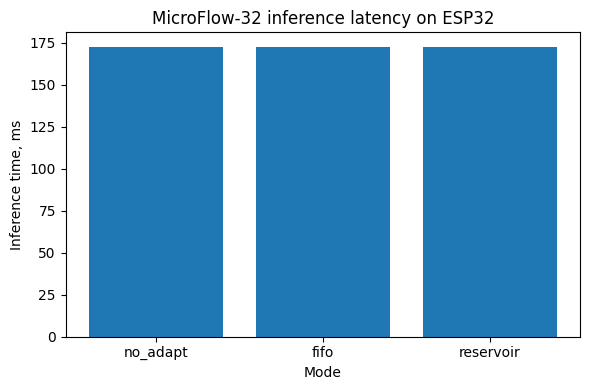

In [8]:
plot_df = sit_up_metrics.set_index("mode").loc[ordered_modes(sit_up_metrics["mode"])]

plt.figure(figsize=(6, 4))
plt.bar(plot_df.index.astype(str), plot_df["inference_ms"])
plt.title("MicroFlow-32 inference latency on ESP32")
plt.xlabel("Mode")
plt.ylabel("Inference time, ms")
save_current_figure("fig_inference_latency_sit_up")
plt.show()

## Plot 2: RAM-Only CL Update Cost

Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_cl_update_cost_sit_up.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_cl_update_cost_sit_up.pdf


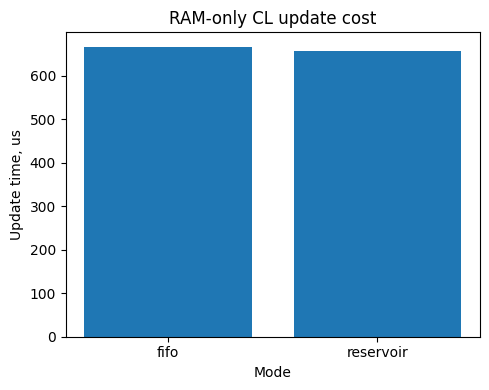

In [9]:
cl_df = sit_up_metrics[sit_up_metrics["mode"].astype(str).isin(["fifo", "reservoir"])].copy()
cl_df = cl_df.set_index("mode").loc[["fifo", "reservoir"]]

plt.figure(figsize=(5, 4))
plt.bar(cl_df.index.astype(str), cl_df["train_update_us_mean"])
plt.title("RAM-only CL update cost")
plt.xlabel("Mode")
plt.ylabel("Update time, us")
save_current_figure("fig_cl_update_cost_sit_up")
plt.show()

## Plot 3: Accepted Rate By Segment And Mode

Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_segment_accepted_rate_sit_up.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_segment_accepted_rate_sit_up.pdf


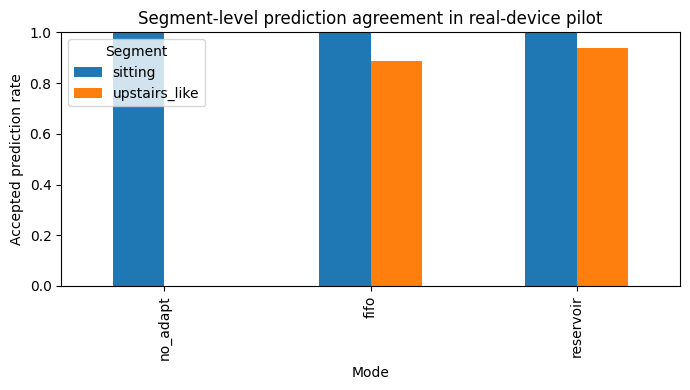

In [10]:
segment_df = sit_up_segment_eval.copy()
segment_df["accepted_rate"] = pd.to_numeric(segment_df["accepted_rate"], errors="coerce")
segment_pivot = segment_df.pivot(index="mode", columns="segment", values="accepted_rate")
segment_pivot = segment_pivot.reindex([mode for mode in MODE_ORDER if mode in segment_pivot.index])

ax = segment_pivot.plot(kind="bar", figsize=(7, 4))
ax.set_title("Segment-level prediction agreement in real-device pilot")
ax.set_xlabel("Mode")
ax.set_ylabel("Accepted prediction rate")
ax.set_ylim(0, 1)
ax.legend(title="Segment")
save_current_figure("fig_segment_accepted_rate_sit_up")
plt.show()

## Plot 4: Prediction Shift On Upstairs-Like Vertical Motion

This is the key pilot figure: no adaptation stays near zero accepted agreement on the upstairs-like segment, while FIFO and reservoir shift predictions toward `Upstairs`/`Downstairs` after supervised labels.

Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_upstairs_like_shift_sit_up.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_upstairs_like_shift_sit_up.pdf


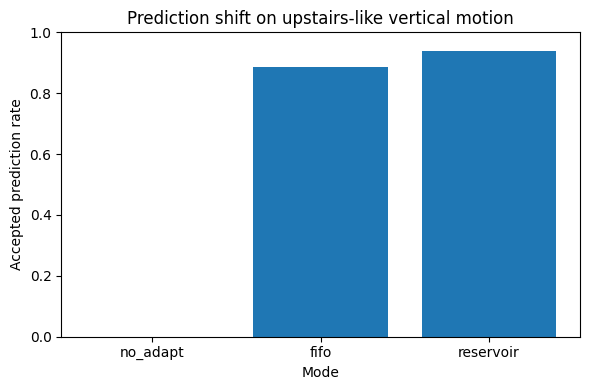

In [11]:
up_df = segment_df[segment_df["segment"] == "upstairs_like"].copy()
up_df["mode"] = pd.Categorical(up_df["mode"], categories=MODE_ORDER, ordered=True)
up_df = up_df.sort_values("mode")

plt.figure(figsize=(6, 4))
plt.bar(up_df["mode"].astype(str), up_df["accepted_rate"])
plt.title("Prediction shift on upstairs-like vertical motion")
plt.xlabel("Mode")
plt.ylabel("Accepted prediction rate")
plt.ylim(0, 1)
save_current_figure("fig_upstairs_like_shift_sit_up")
plt.show()

## Prediction Class Distribution Parsing

In [12]:
def parse_pred_counts(raw: str) -> dict[str, int]:
    counts: dict[str, int] = {}
    if not isinstance(raw, str) or raw.strip() == "":
        return counts
    for part in raw.split(";"):
        if not part:
            continue
        label, value = part.split("=", maxsplit=1)
        counts[label] = int(value)
    return counts

dist_rows = []
for _, row in segment_df.iterrows():
    for predicted_label, count in parse_pred_counts(row["pred_counts"]).items():
        dist_rows.append(
            {
                "mode": row["mode"],
                "segment": row["segment"],
                "predicted_label": predicted_label,
                "count": count,
            }
        )

prediction_distribution = pd.DataFrame(dist_rows)
prediction_distribution_path = TABLE_DIR / "table_prediction_distribution_sit_up.csv"
prediction_distribution.to_csv(prediction_distribution_path, index=False)
print(f"Saved: {prediction_distribution_path}")
prediction_distribution

Saved: /home/g00n3r/projects/esp32_cl_har/results/tables/table_prediction_distribution_sit_up.csv


,mode,segment,predicted_label,count
0,no_adapt,sitting,Sitting,18
1,no_adapt,upstairs_like,Sitting,27
2,fifo,sitting,Sitting,15
3,fifo,upstairs_like,Sitting,4
4,fifo,upstairs_like,Upstairs,31
5,reservoir,sitting,Sitting,17
6,reservoir,upstairs_like,Downstairs,4
7,reservoir,upstairs_like,Sitting,2
8,reservoir,upstairs_like,Upstairs,27


## Plot 5: Prediction Distribution For Upstairs-Like Segment

Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_prediction_distribution_upstairs_like.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_prediction_distribution_upstairs_like.pdf


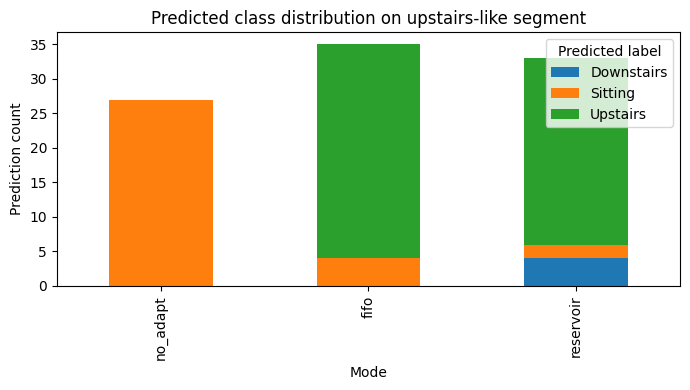

In [13]:
up_dist = prediction_distribution[prediction_distribution["segment"] == "upstairs_like"].copy()
dist_pivot = up_dist.pivot_table(
    index="mode",
    columns="predicted_label",
    values="count",
    aggfunc="sum",
    fill_value=0,
)
dist_pivot = dist_pivot.reindex([mode for mode in MODE_ORDER if mode in dist_pivot.index])

ax = dist_pivot.plot(kind="bar", stacked=True, figsize=(7, 4))
ax.set_title("Predicted class distribution on upstairs-like segment")
ax.set_xlabel("Mode")
ax.set_ylabel("Prediction count")
ax.legend(title="Predicted label")
save_current_figure("fig_prediction_distribution_upstairs_like")
plt.show()

## Interpretation

The no-adaptation run classified the upstairs-like segment as `Sitting`, despite visible upward hand motion in the IMU stream and a clear drop in confidence. FIFO and reservoir adaptation shifted predictions toward the `Upstairs`/`Downstairs` classes after supervised UART labels. Reservoir showed a slightly higher accepted rate in this pilot, but this single short run is too small to claim statistical superiority.

The main publishable resource result is that the RAM-only CL update overhead is below 1% of MicroFlow-32 inference time. This supports the feasibility of replay-based in-session continual learning on ESP32. The pilot should be described as a real-device sanity check, not as a full 6-class HAR benchmark and not as a real staircase benchmark.

## Optional: Compare With Previous Standing-Like Pilot

The previous pilot is kept as a secondary sanity check. It should not be overemphasized because the second segment was standing-like small movement rather than a clean HAR activity.

In [14]:
def compact_run_table(df: pd.DataFrame, pilot_name: str) -> pd.DataFrame:
    metrics = prepare_comparison(df)
    out = metrics[["mode", "inference_ms", "train_update_us_mean"]].copy()
    out.insert(0, "pilot_name", pilot_name)
    return out

optional_tables = [compact_run_table(sit_up_comparison, "sitting_vs_upstairs_like")]
if pilot_2class_comparison is not None:
    optional_tables.append(compact_run_table(pilot_2class_comparison, "earlier_standing_like"))

pilot_comparison_compact = pd.concat(optional_tables, ignore_index=True)
pilot_comparison_compact_path = TABLE_DIR / "table_optional_pilot_comparison.csv"
pilot_comparison_compact.to_csv(pilot_comparison_compact_path, index=False)
print(f"Saved: {pilot_comparison_compact_path}")
pilot_comparison_compact

Saved: /home/g00n3r/projects/esp32_cl_har/results/tables/table_optional_pilot_comparison.csv


,pilot_name,mode,inference_ms,train_update_us_mean
0,sitting_vs_upstairs_like,no_adapt,172.511911,NaN
1,sitting_vs_upstairs_like,fifo,172.289640,666.5
2,sitting_vs_upstairs_like,reservoir,172.324380,656.0
3,earlier_standing_like,no_adapt,172.508289,NaN
4,earlier_standing_like,fifo,172.416680,664.5
5,earlier_standing_like,reservoir,172.274080,658.0


## MicroFlow Feature Extractor Latency Ablation

This figure uses the latency checkpoints recorded in `DEVLOG.md` for the streaming ESP32 runs. It explains why the embedded CL path uses MicroFlow-32 as the primary frozen feature extractor while MicroFlow-64 remains a stronger reference path.



In [15]:
microflow_latency = pd.DataFrame([
    {
        "extractor": "MicroFlow-64",
        "feature_dim": 64,
        "mean_latency_ms": 298.683,
        "replay_ram_kib": 24.0,
        "source": "DEVLOG Phase 3j, 20-attempt streaming mean",
    },
    {
        "extractor": "MicroFlow-32",
        "feature_dim": 32,
        "mean_latency_ms": 172.017,
        "replay_ram_kib": 12.0,
        "source": "DEVLOG Phase 3m, 20-attempt streaming mean",
    },
])

microflow_latency["latency_reduction_vs_64_pct"] = (
    1.0 - microflow_latency["mean_latency_ms"] / microflow_latency.loc[0, "mean_latency_ms"]
) * 100.0

microflow_latency.to_csv(TABLE_DIR / "table_microflow_latency_ablation.csv", index=False)
microflow_latency



,extractor,feature_dim,mean_latency_ms,replay_ram_kib,source,latency_reduction_vs_64_pct
0,MicroFlow-64,64,298.683,24.0,"DEVLOG Phase 3j, 20-attempt streaming mean",0.000000
1,MicroFlow-32,32,172.017,12.0,"DEVLOG Phase 3m, 20-attempt streaming mean",42.408172


Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_microflow_latency_ablation.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_microflow_latency_ablation.pdf


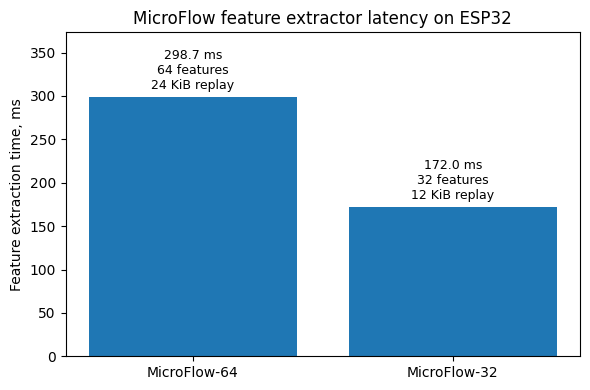

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(microflow_latency["extractor"], microflow_latency["mean_latency_ms"])
ax.set_title("MicroFlow feature extractor latency on ESP32")
ax.set_ylabel("Feature extraction time, ms")
ax.set_ylim(0, max(microflow_latency["mean_latency_ms"]) * 1.25)

for idx, row in microflow_latency.iterrows():
    ax.text(
        idx,
        row["mean_latency_ms"] + 6,
        f"{row['mean_latency_ms']:.1f} ms\n{int(row['feature_dim'])} features\n{row['replay_ram_kib']:.0f} KiB replay",
        ha="center",
        va="bottom",
        fontsize=9,
    )

save_current_figure("fig_microflow_latency_ablation")
plt.show()



### MicroFlow Latency Interpretation

MicroFlow-32 reduced the streaming feature extraction latency from approximately 298.7 ms to 172.0 ms and halved the replay memory estimate from 24 KiB to 12 KiB. This is why MicroFlow-32 is used as the primary embedded path for the RAM-only CL experiments, while MicroFlow-64 remains a reference/stronger baseline rather than the main ESP32 path.



## Attempt-Level Dynamics

These plots use the existing parsed `PRED`, `LABEL`, and `TRAIN` CSV files for the Sitting vs upstairs-like vertical hand-motion pilot. They show prediction behavior over attempts, not final benchmark accuracy. Vertical dashed lines mark the manually selected transition from the sitting segment to the upstairs-like segment; dotted markers show TRAIN events for FIFO/reservoir runs.



In [17]:
SIT_UP_RUN_FILES = {
    "no_adapt": {
        "pred": ROOT / "logs" / "parsed" / "pilot_sit_up" / "no_adapt" / "sit_up_no_adapt_2026-05-09_pred.csv",
        "label": ROOT / "logs" / "parsed" / "pilot_sit_up" / "no_adapt" / "sit_up_no_adapt_2026-05-09_label.csv",
        "train": ROOT / "logs" / "parsed" / "pilot_sit_up" / "no_adapt" / "sit_up_no_adapt_2026-05-09_train.csv",
    },
    "fifo": {
        "pred": ROOT / "logs" / "parsed" / "pilot_sit_up" / "fifo" / "sit_up_fifo_2026-05-09_pred.csv",
        "label": ROOT / "logs" / "parsed" / "pilot_sit_up" / "fifo" / "sit_up_fifo_2026-05-09_label.csv",
        "train": ROOT / "logs" / "parsed" / "pilot_sit_up" / "fifo" / "sit_up_fifo_2026-05-09_train.csv",
    },
    "reservoir": {
        "pred": ROOT / "logs" / "parsed" / "pilot_sit_up" / "reservoir" / "sit_up_reservoir_2026-05-09_pred.csv",
        "label": ROOT / "logs" / "parsed" / "pilot_sit_up" / "reservoir" / "sit_up_reservoir_2026-05-09_label.csv",
        "train": ROOT / "logs" / "parsed" / "pilot_sit_up" / "reservoir" / "sit_up_reservoir_2026-05-09_train.csv",
    },
}

CLASS_ORDER = ["Walking", "Jogging", "Upstairs", "Downstairs", "Sitting", "Standing"]
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_ORDER)}

def load_optional_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

attempt_data = {}
for mode, files in SIT_UP_RUN_FILES.items():
    pred = load_optional_csv(files["pred"])
    label = load_optional_csv(files["label"])
    train = load_optional_csv(files["train"])
    if not pred.empty:
        pred["attempt"] = pd.to_numeric(pred["attempt"], errors="coerce")
        pred["conf"] = pd.to_numeric(pred["conf"], errors="coerce")
        pred["class_id"] = pred["label"].map(CLASS_TO_ID)
    if not label.empty:
        label["attempt"] = pd.to_numeric(label["attempt"], errors="coerce")
    if not train.empty:
        train["attempt"] = pd.to_numeric(train["attempt"], errors="coerce")
        train["step"] = pd.to_numeric(train["step"], errors="coerce")
    attempt_data[mode] = {"pred": pred, "label": label, "train": train}

segment_ranges = {
    (row["mode"], row["segment"]): (int(row["attempt_start"]), int(row["attempt_end"]))
    for _, row in sit_up_segment_eval.iterrows()
}

summary_rows = []
for mode in MODE_ORDER:
    data = attempt_data[mode]
    train_attempts = [] if data["train"].empty else [int(x) for x in data["train"]["attempt"].dropna().tolist()]
    label_attempts = [] if data["label"].empty else sorted({int(x) for x in data["label"]["attempt"].dropna().tolist()})
    sitting = segment_ranges.get((mode, "sitting"), (None, None))
    upstairs = segment_ranges.get((mode, "upstairs_like"), (None, None))
    summary_rows.append({
        "mode": mode,
        "sitting_attempts": f"{sitting[0]}-{sitting[1]}",
        "upstairs_like_attempts": f"{upstairs[0]}-{upstairs[1]}",
        "label_attempts": ";".join(map(str, label_attempts)),
        "train_attempts": ";".join(map(str, train_attempts)),
    })

attempt_event_summary = pd.DataFrame(summary_rows)
attempt_event_summary.to_csv(TABLE_DIR / "table_attempt_level_events_sit_up.csv", index=False)
attempt_event_summary



,mode,sitting_attempts,upstairs_like_attempts,label_attempts,train_attempts
0,no_adapt,1-18,19-45,,
1,fifo,1-15,16-50,8;9;26;27,9;27
2,reservoir,1-17,18-50,9;10;27;28,10;28


Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_prediction_class_attempt_sit_up.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_prediction_class_attempt_sit_up.pdf


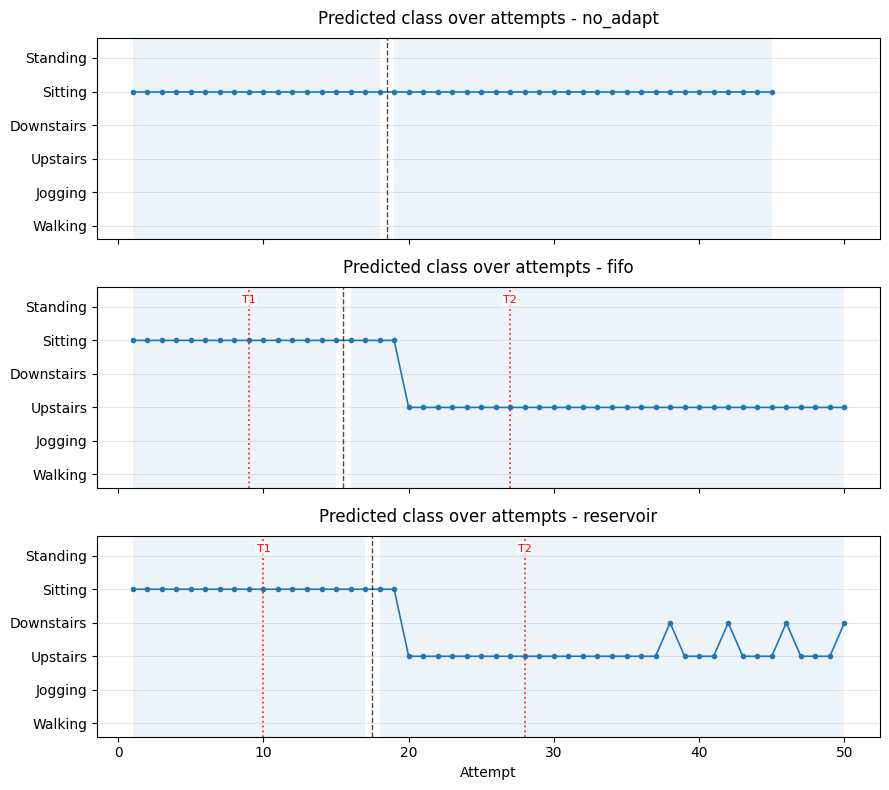

In [18]:
fig, axes = plt.subplots(len(MODE_ORDER), 1, figsize=(9, 8), sharex=True, sharey=True)

for ax, mode in zip(axes, MODE_ORDER):
    pred = attempt_data[mode]["pred"]
    train = attempt_data[mode]["train"]
    if pred.empty:
        ax.set_title(f"Predicted class over attempts - {mode}: missing data")
        continue

    ax.plot(pred["attempt"], pred["class_id"], marker="o", linewidth=1.2, markersize=3)
    ax.set_title(f"Predicted class over attempts - {mode}", pad=10)
    ax.set_ylim(-0.4, len(CLASS_ORDER) - 0.4)
    ax.set_yticks(range(len(CLASS_ORDER)))
    ax.set_yticklabels(CLASS_ORDER)
    ax.grid(True, axis="y", alpha=0.3)

    sitting = segment_ranges.get((mode, "sitting"))
    upstairs = segment_ranges.get((mode, "upstairs_like"))
    if sitting and upstairs:
        ax.axvspan(sitting[0], sitting[1], alpha=0.08, label="sitting")
        ax.axvspan(upstairs[0], upstairs[1], alpha=0.08, label="upstairs-like")
        ax.axvline(sitting[1] + 0.5, linestyle="--", linewidth=1, color="black", alpha=0.7)

    if not train.empty:
        for _, row in train.iterrows():
            ax.axvline(row["attempt"], linestyle=":", linewidth=1.3, color="red", alpha=0.8)
            ax.text(
                row["attempt"],
                0.96,
                f"T{int(row['step'])}",
                color="red",
                ha="center",
                va="top",
                fontsize=8,
                transform=ax.get_xaxis_transform(),
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 1},
            )

axes[-1].set_xlabel("Attempt")
save_current_figure("fig_prediction_class_attempt_sit_up")
plt.show()



Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_confidence_attempt_sit_up.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_confidence_attempt_sit_up.pdf


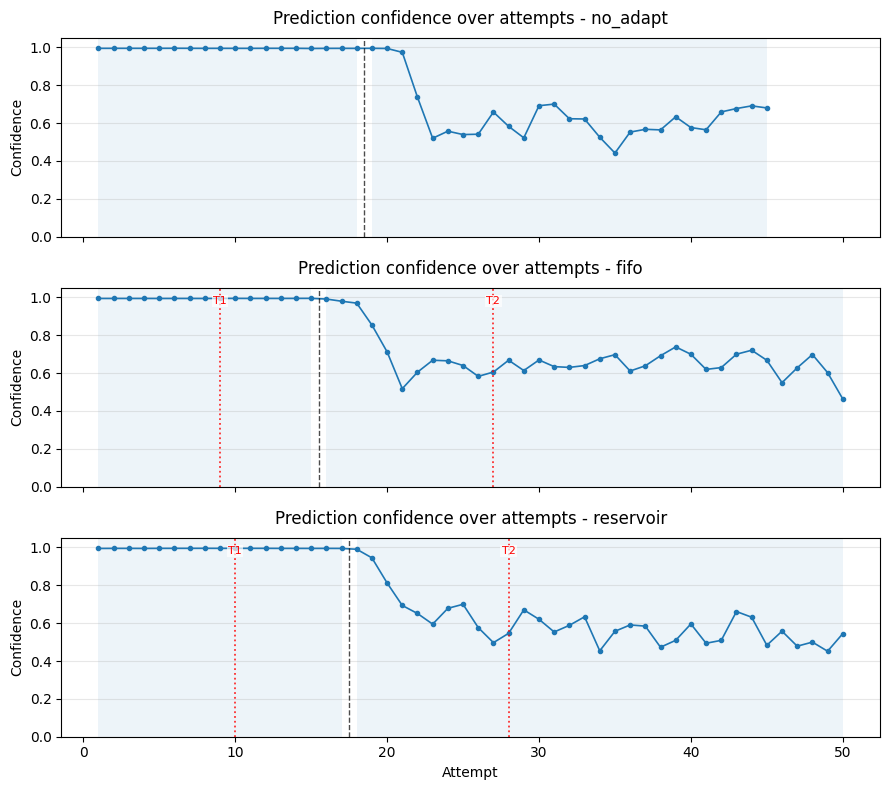

In [19]:
fig, axes = plt.subplots(len(MODE_ORDER), 1, figsize=(9, 8), sharex=True, sharey=True)

for ax, mode in zip(axes, MODE_ORDER):
    pred = attempt_data[mode]["pred"]
    train = attempt_data[mode]["train"]
    if pred.empty:
        ax.set_title(f"Prediction confidence over attempts - {mode}: missing data")
        continue

    ax.plot(pred["attempt"], pred["conf"], marker="o", linewidth=1.2, markersize=3)
    ax.set_title(f"Prediction confidence over attempts - {mode}", pad=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Confidence")
    ax.grid(True, axis="y", alpha=0.3)

    sitting = segment_ranges.get((mode, "sitting"))
    upstairs = segment_ranges.get((mode, "upstairs_like"))
    if sitting and upstairs:
        ax.axvspan(sitting[0], sitting[1], alpha=0.08, label="sitting")
        ax.axvspan(upstairs[0], upstairs[1], alpha=0.08, label="upstairs-like")
        ax.axvline(sitting[1] + 0.5, linestyle="--", linewidth=1, color="black", alpha=0.7)

    if not train.empty:
        for _, row in train.iterrows():
            ax.axvline(row["attempt"], linestyle=":", linewidth=1.3, color="red", alpha=0.8)
            ax.text(
                row["attempt"],
                0.96,
                f"T{int(row['step'])}",
                color="red",
                ha="center",
                va="top",
                fontsize=8,
                transform=ax.get_xaxis_transform(),
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 1},
            )

axes[-1].set_xlabel("Attempt")
save_current_figure("fig_confidence_attempt_sit_up")
plt.show()



### Attempt-Level Interpretation

The attempt-level plots make the pilot easier to interpret than aggregate bars alone. In the no-adaptation run, the upstairs-like segment remains classified as Sitting, although confidence drops during motion. In FIFO and reservoir runs, the second supervised update is followed by predictions shifting toward Upstairs/Downstairs classes. These plots should still be described as pilot dynamics, not as a full HAR benchmark.



## Final Paper-Ready Summary

- The ESP32-WROOM-32 prototype executed MicroFlow-32 inference at approximately 172 ms per window.
- The RAM-only `OnlineLayer32` update took approximately 0.66 ms for FIFO/reservoir replay in the `Sitting` vs upstairs-like vertical hand-motion pilot.
- Replay memory was fixed at `6 x 16 x 32 x 4` bytes, approximately 12 KiB.
- In the `Sitting` vs upstairs-like pilot, no adaptation remained at 0% accepted rate on the upstairs-like segment, while FIFO and reservoir reached approximately 88.6% and 93.9% respectively.
- These results support the feasibility of replay-based in-session continual learning on ESP32, with non-volatile persistence left for future work.


## Device-Side Target-User WISDM CL

This section analyzes the isolated ESP32 run for held-out `target_user=19`. Unlike the earlier `balanced_600` sanity check, this is a target-user continual-learning proof-of-concept: the fold-specific MicroFlow-32 model was trained without user 19, adaptation uses labeled user-19 windows, and evaluation is performed on held-out user-19 windows. It is still not a full LOSO benchmark; it is a staged device-side CL result.


In [20]:
wisdm_user19_summary_path = TABLE_DIR / "wisdm_user19_device_cl_summary.csv"
wisdm_user19_class_path = TABLE_DIR / "wisdm_user19_device_cl_per_class.csv"
wisdm_user19_train_path = TABLE_DIR / "wisdm_user19_device_cl_train.csv"

wisdm_user19_summary = pd.read_csv(wisdm_user19_summary_path)
wisdm_user19_class = pd.read_csv(wisdm_user19_class_path)
wisdm_user19_train = pd.read_csv(wisdm_user19_train_path)

wisdm_user19_summary


,source_log,tag,target_user,total,budget_per_class,lr,labels_per_update,batch_size,policy,split_selected_adaptation,...,train_steps,pre_held_out_accuracy,post_held_out_accuracy,accuracy_delta_pp,pre_held_out_total,post_held_out_total,mean_infer_us,downstairs_pre_recall,downstairs_post_recall,downstairs_delta_pp
0,logs/raw/wisdm_user19_device_cl/wisdm_user19_d...,wisdm_user19_target_cl,19,208,10,0.01,10,12,reservoir,56,...,5,0.730263,0.802632,7.2368,152,152,178257,0.0,0.785714,78.5714
1,logs/raw/wisdm_user19_device_cl/wisdm_user19_d...,wisdm_user19_target_cl,19,208,10,0.01,10,12,fifo,56,...,5,0.730263,0.802632,7.2368,152,152,174814,0.0,0.785714,78.5714


In [21]:
wisdm_user19_summary_fmt = wisdm_user19_summary.copy()
wisdm_user19_summary_fmt["pre_accuracy_pct"] = wisdm_user19_summary_fmt["pre_held_out_accuracy"] * 100.0
wisdm_user19_summary_fmt["post_accuracy_pct"] = wisdm_user19_summary_fmt["post_held_out_accuracy"] * 100.0
wisdm_user19_summary_fmt["downstairs_pre_recall_pct"] = wisdm_user19_summary_fmt["downstairs_pre_recall"] * 100.0
wisdm_user19_summary_fmt["downstairs_post_recall_pct"] = wisdm_user19_summary_fmt["downstairs_post_recall"] * 100.0
wisdm_user19_summary_fmt["inference_ms"] = wisdm_user19_summary_fmt["mean_infer_us"] / 1000.0

wisdm_user19_train_summary = (
    wisdm_user19_train.groupby("policy", as_index=False)
    .agg(
        update_us_mean=("update_us", "mean"),
        update_us_min=("update_us", "min"),
        update_us_max=("update_us", "max"),
        sample_us_mean=("sample_us", "mean"),
        train_updates=("step", "count"),
    )
)

wisdm_user19_table = wisdm_user19_summary_fmt.merge(wisdm_user19_train_summary, on="policy", how="left")
wisdm_user19_table["cl_update_vs_infer_pct"] = (
    wisdm_user19_table["update_us_mean"] / wisdm_user19_table["mean_infer_us"] * 100.0
)
wisdm_user19_table = wisdm_user19_table[[
    "policy",
    "target_user",
    "split_selected_adaptation",
    "split_held_out",
    "budget_per_class",
    "lr",
    "train_updates",
    "pre_accuracy_pct",
    "post_accuracy_pct",
    "accuracy_delta_pp",
    "downstairs_pre_recall_pct",
    "downstairs_post_recall_pct",
    "downstairs_delta_pp",
    "inference_ms",
    "update_us_mean",
    "cl_update_vs_infer_pct",
]]

wisdm_user19_table.to_csv(TABLE_DIR / "table_wisdm_user19_device_cl_summary.csv", index=False)
wisdm_user19_table.to_markdown(TABLE_DIR / "table_wisdm_user19_device_cl_summary.md", index=False)
wisdm_user19_table


,policy,target_user,split_selected_adaptation,split_held_out,budget_per_class,lr,train_updates,pre_accuracy_pct,post_accuracy_pct,accuracy_delta_pp,downstairs_pre_recall_pct,downstairs_post_recall_pct,downstairs_delta_pp,inference_ms,update_us_mean,cl_update_vs_infer_pct
0,reservoir,19,56,152,10,0.01,5,73.02632,80.263156,7.2368,0.0,78.571427,78.5714,178.257,604.6,0.339173
1,fifo,19,56,152,10,0.01,5,73.02632,80.263156,7.2368,0.0,78.571427,78.5714,174.814,602.8,0.344824


Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_wisdm_user19_accuracy_pre_post.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_wisdm_user19_accuracy_pre_post.pdf


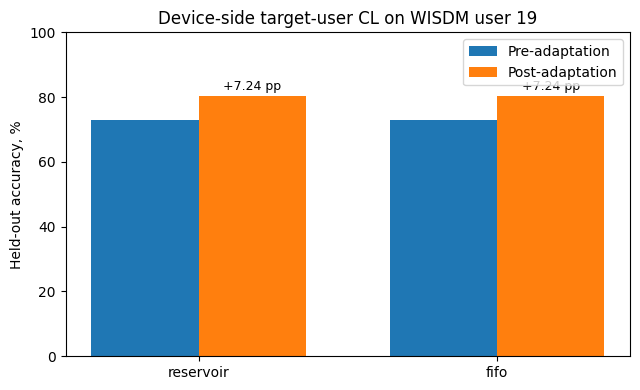

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 4))
x = list(range(len(wisdm_user19_summary_fmt)))
width = 0.36
ax.bar([i - width / 2 for i in x], wisdm_user19_summary_fmt["pre_accuracy_pct"], width=width, label="Pre-adaptation")
ax.bar([i + width / 2 for i in x], wisdm_user19_summary_fmt["post_accuracy_pct"], width=width, label="Post-adaptation")
ax.set_xticks(x)
ax.set_xticklabels(wisdm_user19_summary_fmt["policy"])
ax.set_ylim(0, 100)
ax.set_ylabel("Held-out accuracy, %")
ax.set_title("Device-side target-user CL on WISDM user 19")
ax.legend()

for i, row in wisdm_user19_summary_fmt.iterrows():
    ax.text(i + width / 2, row["post_accuracy_pct"] + 2, f"+{row['accuracy_delta_pp']:.2f} pp", ha="center", fontsize=9)

save_current_figure("fig_wisdm_user19_accuracy_pre_post")
plt.show()


Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_wisdm_user19_downstairs_recall_pre_post.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_wisdm_user19_downstairs_recall_pre_post.pdf


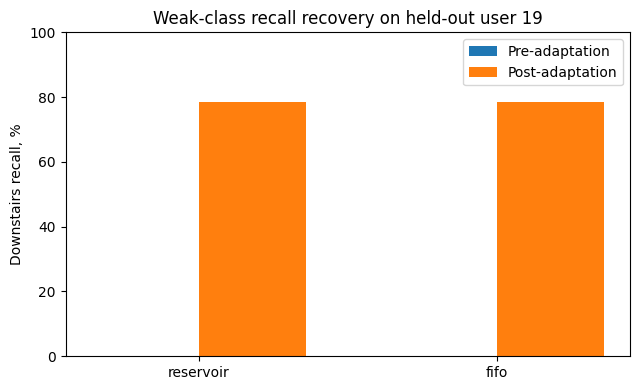

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar([i - width / 2 for i in x], wisdm_user19_summary_fmt["downstairs_pre_recall_pct"], width=width, label="Pre-adaptation")
ax.bar([i + width / 2 for i in x], wisdm_user19_summary_fmt["downstairs_post_recall_pct"], width=width, label="Post-adaptation")
ax.set_xticks(x)
ax.set_xticklabels(wisdm_user19_summary_fmt["policy"])
ax.set_ylim(0, 100)
ax.set_ylabel("Downstairs recall, %")
ax.set_title("Weak-class recall recovery on held-out user 19")
ax.legend()

save_current_figure("fig_wisdm_user19_downstairs_recall_pre_post")
plt.show()


In [24]:
def policy_from_source_log(value: str) -> str:
    if "fifo" in value:
        return "fifo"
    if "reservoir" in value:
        return "reservoir"
    return "unknown"

wisdm_user19_class_fmt = wisdm_user19_class.copy()
wisdm_user19_class_fmt["policy"] = wisdm_user19_class_fmt["source_log"].map(policy_from_source_log)
wisdm_user19_heldout = wisdm_user19_class_fmt[wisdm_user19_class_fmt["split"].eq("held_out")].copy()
wisdm_user19_heldout["recall_pct"] = wisdm_user19_heldout["recall"] * 100.0

wisdm_user19_heldout_table = wisdm_user19_heldout[[
    "policy", "phase", "class", "name", "support", "correct", "recall_pct"
]].sort_values(["policy", "class", "phase"])

wisdm_user19_heldout_table.to_csv(TABLE_DIR / "table_wisdm_user19_device_cl_per_class_heldout.csv", index=False)
wisdm_user19_heldout_table.to_markdown(TABLE_DIR / "table_wisdm_user19_device_cl_per_class_heldout.md", index=False)
wisdm_user19_heldout_table


,policy,phase,class,name,support,correct,recall_pct
30,fifo,post,0,Walking,65,65,100.000000
24,fifo,pre,0,Walking,65,65,100.000000
31,fifo,post,1,Jogging,20,20,100.000000
25,fifo,pre,1,Jogging,20,20,100.000000
32,fifo,post,2,Upstairs,40,13,32.500000
26,fifo,pre,2,Upstairs,40,13,32.500000
33,fifo,post,3,Downstairs,14,11,78.571427
27,fifo,pre,3,Downstairs,14,0,0.000000
34,fifo,post,4,Sitting,1,1,100.000000
28,fifo,pre,4,Sitting,1,1,100.000000


Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_wisdm_user19_per_class_recall.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_wisdm_user19_per_class_recall.pdf


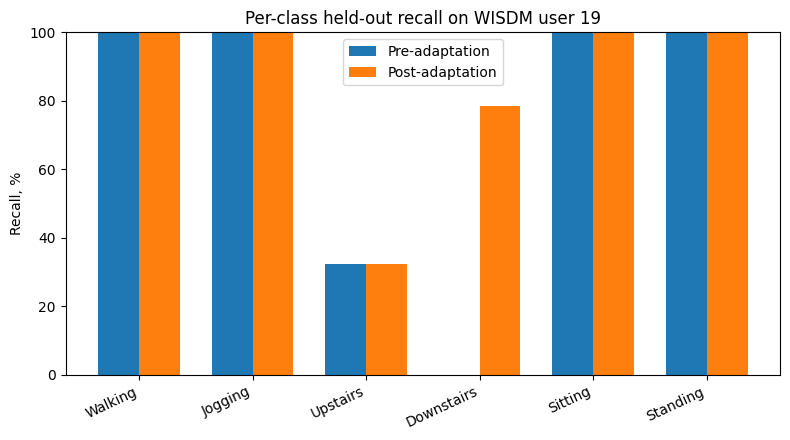

In [25]:
reservoir_heldout = wisdm_user19_heldout[wisdm_user19_heldout["policy"].eq("reservoir")].copy()
class_names = list(reservoir_heldout[reservoir_heldout["phase"].eq("pre")].sort_values("class")["name"])
indices = list(range(len(class_names)))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 4.5))
for offset, phase in [(-width / 2, "pre"), (width / 2, "post")]:
    phase_rows = reservoir_heldout[reservoir_heldout["phase"].eq(phase)].sort_values("class")
    label = "Pre-adaptation" if phase == "pre" else "Post-adaptation"
    ax.bar([i + offset for i in indices], phase_rows["recall_pct"], width=width, label=label)

ax.set_xticks(indices)
ax.set_xticklabels(class_names, rotation=25, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Recall, %")
ax.set_title("Per-class held-out recall on WISDM user 19")
ax.legend()

save_current_figure("fig_wisdm_user19_per_class_recall")
plt.show()


Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_wisdm_user19_update_cost.png
Saved: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_wisdm_user19_update_cost.pdf


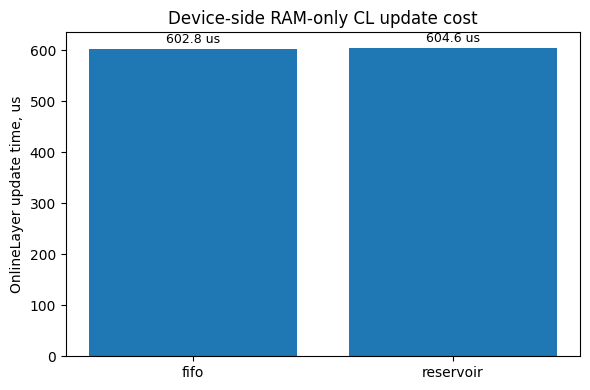

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(wisdm_user19_train_summary["policy"], wisdm_user19_train_summary["update_us_mean"])
ax.set_ylabel("OnlineLayer update time, us")
ax.set_title("Device-side RAM-only CL update cost")

for i, row in wisdm_user19_train_summary.iterrows():
    ax.text(i, row["update_us_mean"] + 12, f"{row['update_us_mean']:.1f} us", ha="center", fontsize=9)

save_current_figure("fig_wisdm_user19_update_cost")
plt.show()


### Device-Side Target-User CL Interpretation

The user-19 run is the strongest WISDM continual-learning result currently available in the project. The pre-adaptation held-out accuracy was 73.03%, and both FIFO and reservoir replay reached 80.26% after 56 labeled adaptation windows. The main change is concentrated in the weak `Downstairs` class, whose held-out recall increased from 0.00% to 78.57%.

FIFO and reservoir are identical in this gate because the adaptation sequence and per-class replay capacity do not yet create a meaningful difference between replacement policies. The result should therefore be used as evidence that RAM-only replay adaptation works on ESP32 for a held-out target user, not as evidence that reservoir is statistically superior.

The update cost remains small compared with MicroFlow-32 inference: approximately 0.60 ms per OnlineLayer update versus approximately 175-178 ms per feature-extraction pass.


<!-- PAPER_READY_UK_FIGURES_V1 -->
## Фінальний набір рисунків для статті

Цей блок генерує окремий україномовний набір фігур у Kwon-подібному стилі: serif-шрифт, чорні контури, штрихування стовпчиків, стримана сітка та компактні підписи. Файли зберігаються у `results/figures/` як PNG і PDF.

Повна confusion matrix для User 19 у логах від 13 травня не збережена: доступні `accuracy`, `support`, `correct` і `recall` по класах. Тому heatmap нижче є матрицею повноти класів до/після адаптації, а не вигаданою матрицею помилок.


In [27]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

# Статейний стиль, близький до графіків Kwon et al.: монохром, hatch-патерни,
# виразні осі та компактні підписи значень.
def apply_kwon_uk_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.labelweight": "bold",
        "axes.edgecolor": "black",
        "axes.linewidth": 0.9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.frameon": False,
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

KWON_HATCHES = ["////", "\\\\\\\\", "xxxx", "....", "----", "++++"]
BAR_FACE = "#d9d9d9"
BAR_EDGE = "black"

MODE_UK = {
    "no_adapt": "Без адаптації",
    "fifo": "FIFO",
    "reservoir": "Reservoir-per-class",
}

CLASS_UK = {
    "Walking": "Ходьба",
    "Jogging": "Біг",
    "Upstairs": "Вгору сходами",
    "Downstairs": "Вниз сходами",
    "Sitting": "Сидіння",
    "Standing": "Стояння",
}

PHASE_UK = {
    "pre": "До адаптації",
    "post": "Після адаптації",
}

apply_kwon_uk_style()


def style_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.tick_params(direction="out", length=3, width=0.8, colors="black")
    if grid_axis:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.45, alpha=0.35)
        ax.set_axisbelow(True)


def save_paper_figure(stem: str):
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    plt.tight_layout()
    plt.savefig(png_path)
    plt.savefig(pdf_path)
    print(f"Збережено: {png_path}")
    print(f"Збережено: {pdf_path}")


def annotate_bars(ax, bars, suffix="", digits=2, y_offset=0.02, rotation=0):
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * y_offset
    for bar in bars:
        height = bar.get_height()
        if pd.isna(height):
            continue
        label = f"{height:.{digits}f}{suffix}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            label,
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=rotation,
        )


def hatch_bars(bars):
    for idx, bar in enumerate(bars):
        bar.set_facecolor(BAR_FACE)
        bar.set_edgecolor(BAR_EDGE)
        bar.set_linewidth(0.8)
        bar.set_hatch(KWON_HATCHES[idx % len(KWON_HATCHES)])


Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_01_system_pipeline_uk.png
Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_01_system_pipeline_uk.pdf


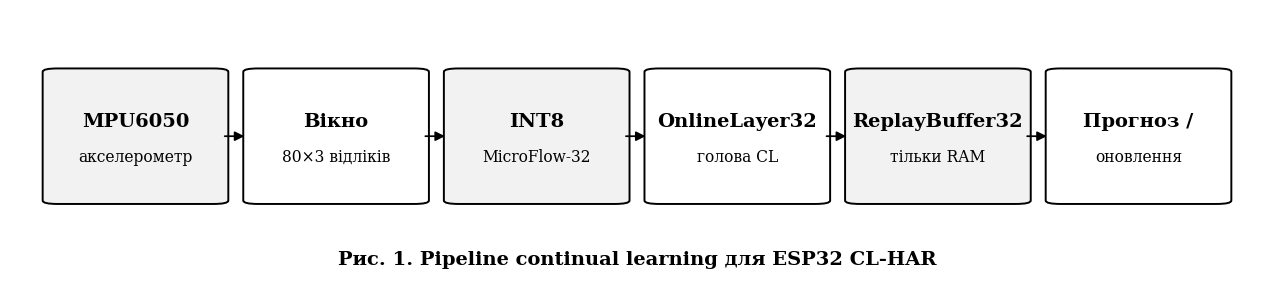

In [28]:
# Рисунок 1: архітектура системи.
fig, ax = plt.subplots(figsize=(9.2, 2.3))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

nodes = [
    ("MPU6050", "акселерометр"),
    ("Вікно", "80×3 відліків"),
    ("INT8", "MicroFlow-32"),
    ("OnlineLayer32", "голова CL"),
    ("ReplayBuffer32", "тільки RAM"),
    ("Прогноз /", "оновлення"),
]

box_w = 0.125
box_h = 0.46
x0 = 0.035
gap = 0.036
y0 = 0.33
for idx, (top, bottom) in enumerate(nodes):
    x = x0 + idx * (box_w + gap)
    patch = FancyBboxPatch(
        (x, y0),
        box_w,
        box_h,
        boxstyle="round,pad=0.012,rounding_size=0.012",
        linewidth=1.0,
        edgecolor="black",
        facecolor="#f2f2f2" if idx % 2 == 0 else "white",
        hatch=None,
    )
    ax.add_patch(patch)
    ax.text(x + box_w / 2, y0 + box_h * 0.62, top, ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(x + box_w / 2, y0 + box_h * 0.34, bottom, ha="center", va="center", fontsize=8)
    if idx < len(nodes) - 1:
        x_start = x + box_w + 0.006
        x_end = x + box_w + gap - 0.008
        arrow = FancyArrowPatch(
            (x_start, y0 + box_h / 2),
            (x_end, y0 + box_h / 2),
            arrowstyle="-|>",
            mutation_scale=10,
            linewidth=0.9,
            color="black",
        )
        ax.add_patch(arrow)

ax.text(0.5, 0.12, "Рис. 1. Pipeline continual learning для ESP32 CL-HAR", ha="center", va="center", fontsize=10, fontweight="bold")
save_paper_figure("fig_01_system_pipeline_uk")
plt.show()


Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_02_microflow32_ablation_latency_ram_uk.png
Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_02_microflow32_ablation_latency_ram_uk.pdf


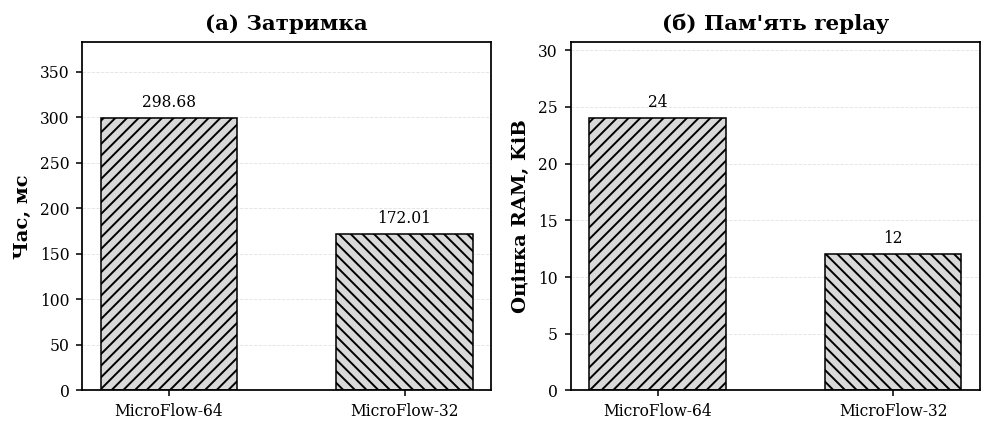

In [29]:
# Рисунок 2: MicroFlow-64 проти MicroFlow-32 за latency і RAM replay.
microflow_latency_uk = pd.DataFrame([
    {"Модель": "MicroFlow-64", "Час інференсу, мс": 298.68, "Replay RAM, KiB": 24.0},
    {"Модель": "MicroFlow-32", "Час інференсу, мс": 172.01, "Replay RAM, KiB": 12.0},
])
microflow_latency_uk["Зменшення часу проти 64, %"] = (
    1.0 - microflow_latency_uk["Час інференсу, мс"] / microflow_latency_uk.loc[0, "Час інференсу, мс"]
) * 100.0
microflow_latency_uk.to_csv(TABLE_DIR / "table_02_microflow_latency_ram_uk.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
metrics = ["Час інференсу, мс", "Replay RAM, KiB"]
ylabels = ["Час, мс", "Оцінка RAM, KiB"]
panel_labels = ["(а) Затримка", "(б) Пам'ять replay"]

for ax, metric, ylabel, panel in zip(axes, metrics, ylabels, panel_labels):
    bars = ax.bar(microflow_latency_uk["Модель"], microflow_latency_uk[metric], width=0.58)
    hatch_bars(bars)
    ax.set_ylabel(ylabel)
    ax.set_title(panel, fontweight="bold")
    ax.set_ylim(0, microflow_latency_uk[metric].max() * 1.28)
    style_axes(ax)
    annotate_bars(ax, bars, digits=2 if "Час" in metric else 0)

save_paper_figure("fig_02_microflow32_ablation_latency_ram_uk")
plt.show()


Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_03_update_cost_vs_inference_uk.png
Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_03_update_cost_vs_inference_uk.pdf


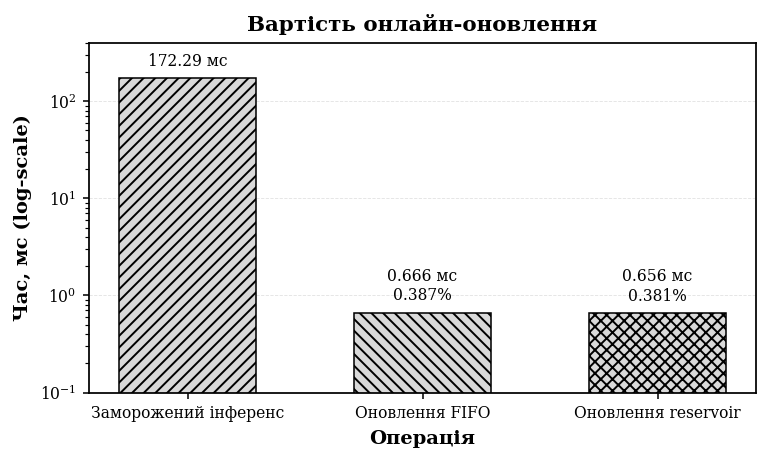

In [30]:
# Рисунок 3: вартість онлайн-оновлення відносно інференсу, log-scale.
latency_row = sit_up_metrics[sit_up_metrics["mode"].astype(str).eq("fifo")].iloc[0]
fifo_row = sit_up_metrics[sit_up_metrics["mode"].astype(str).eq("fifo")].iloc[0]
reservoir_row = sit_up_metrics[sit_up_metrics["mode"].astype(str).eq("reservoir")].iloc[0]
update_cost_uk = pd.DataFrame([
    {"Операція": "Заморожений інференс", "Час, мс": float(latency_row["inference_ms"]), "Частка від інференсу, %": 100.0},
    {"Операція": "Оновлення FIFO", "Час, мс": float(fifo_row["train_update_ms"]), "Частка від інференсу, %": float(fifo_row["cl_update_vs_infer_pct"])},
    {"Операція": "Оновлення reservoir", "Час, мс": float(reservoir_row["train_update_ms"]), "Частка від інференсу, %": float(reservoir_row["cl_update_vs_infer_pct"])},
])
update_cost_uk.to_csv(TABLE_DIR / "table_03_update_cost_vs_inference_uk.csv", index=False)

fig, ax = plt.subplots(figsize=(5.6, 3.4))
bars = ax.bar(update_cost_uk["Операція"], update_cost_uk["Час, мс"], width=0.58)
hatch_bars(bars)
ax.set_yscale("log")
ax.set_ylabel("Час, мс (log-scale)")
ax.set_xlabel("Операція")
ax.set_title("Вартість онлайн-оновлення", fontweight="bold")
ax.set_ylim(0.1, 400)
style_axes(ax)
for idx, bar in enumerate(bars):
    row = update_cost_uk.iloc[idx]
    height = bar.get_height()
    pct = float(row["Частка від інференсу, %"])
    if idx == 0:
        label = f"{height:.2f} мс"
    else:
        label = f"{height:.3f} мс\n{pct:.3f}%"
    ax.text(bar.get_x() + bar.get_width() / 2, height * 1.22, label, ha="center", va="bottom", fontsize=8)

save_paper_figure("fig_03_update_cost_vs_inference_uk")
plt.show()


Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_04_hardware_adaptation_acceptance_uk.png
Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_04_hardware_adaptation_acceptance_uk.pdf


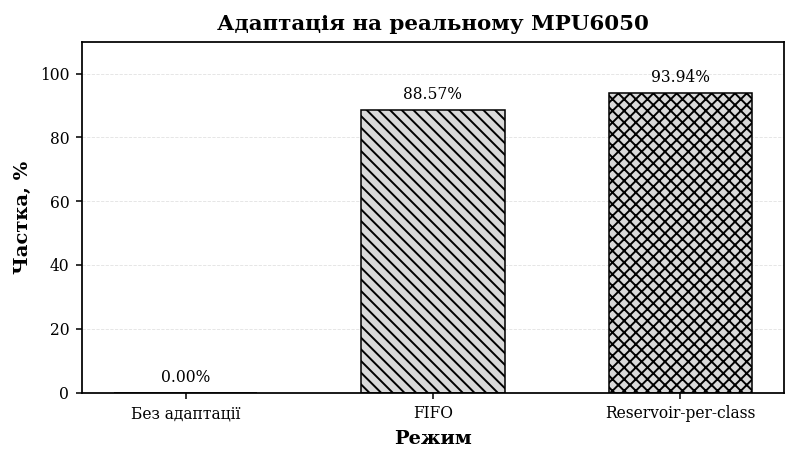

In [31]:
# Рисунок 4: апаратна адаптація на реальному MPU6050.
upstairs_like_uk = segment_df[segment_df["segment"].eq("upstairs_like")].copy()
upstairs_like_uk["mode"] = pd.Categorical(upstairs_like_uk["mode"], categories=MODE_ORDER, ordered=True)
upstairs_like_uk = upstairs_like_uk.sort_values("mode")
upstairs_like_uk["Режим"] = upstairs_like_uk["mode"].astype(str).map(MODE_UK)
upstairs_like_uk["Прийняті правильні передбачення, %"] = upstairs_like_uk["accepted_rate"] * 100.0
upstairs_like_uk[["Режим", "Прийняті правильні передбачення, %"]].to_csv(
    TABLE_DIR / "table_04_hardware_adaptation_uk.csv", index=False
)

fig, ax = plt.subplots(figsize=(5.8, 3.4))
bars = ax.bar(upstairs_like_uk["Режим"], upstairs_like_uk["Прийняті правильні передбачення, %"], width=0.58)
hatch_bars(bars)
ax.set_ylabel("Частка, %")
ax.set_xlabel("Режим")
ax.set_title("Адаптація на реальному MPU6050", fontweight="bold")
ax.set_ylim(0, 110)
style_axes(ax)
annotate_bars(ax, bars, suffix="%", digits=2)
save_paper_figure("fig_04_hardware_adaptation_acceptance_uk")
plt.show()


Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_05_user19_accuracy_pre_post_uk.png
Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_05_user19_accuracy_pre_post_uk.pdf


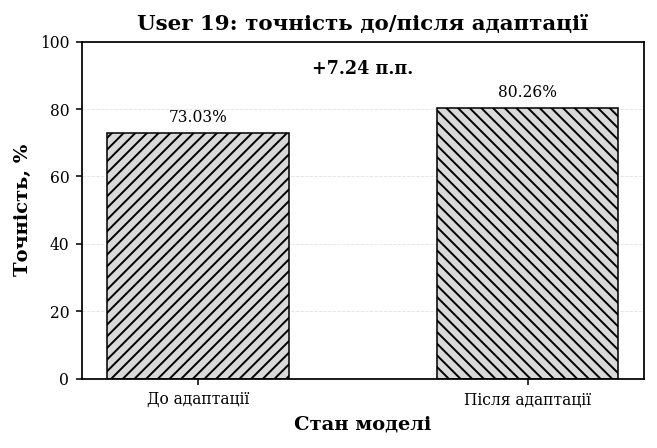

In [32]:
# Рисунок 5: User 19, accuracy до/після адаптації.
user19_main = wisdm_user19_summary_fmt[wisdm_user19_summary_fmt["policy"].eq("reservoir")].iloc[0]
user19_accuracy_uk = pd.DataFrame([
    {"Стан": "До адаптації", "Точність, %": float(user19_main["pre_accuracy_pct"])},
    {"Стан": "Після адаптації", "Точність, %": float(user19_main["post_accuracy_pct"])},
])
user19_accuracy_uk.to_csv(TABLE_DIR / "table_05_user19_accuracy_uk.csv", index=False)

fig, ax = plt.subplots(figsize=(4.8, 3.3))
bars = ax.bar(user19_accuracy_uk["Стан"], user19_accuracy_uk["Точність, %"], width=0.55)
hatch_bars(bars)
ax.set_ylabel("Точність, %")
ax.set_xlabel("Стан моделі")
ax.set_title("User 19: точність до/після адаптації", fontweight="bold")
ax.set_ylim(0, 100)
style_axes(ax)
annotate_bars(ax, bars, suffix="%", digits=2)
ax.text(0.5, 92, f"+{float(user19_main['accuracy_delta_pp']):.2f} п.п.", ha="center", va="center", fontsize=9, fontweight="bold")
save_paper_figure("fig_05_user19_accuracy_pre_post_uk")
plt.show()


Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_06_user19_downstairs_recall_uk.png
Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_06_user19_downstairs_recall_uk.pdf


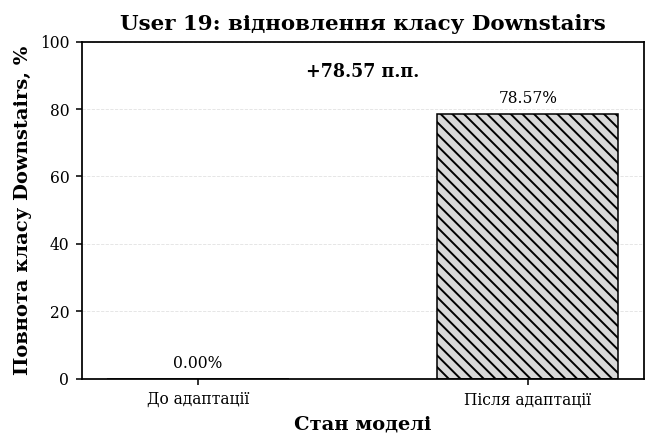

In [33]:
# Рисунок 6: User 19, відновлення Downstairs recall.
user19_downstairs_uk = pd.DataFrame([
    {"Стан": "До адаптації", "Повнота Downstairs, %": float(user19_main["downstairs_pre_recall_pct"])},
    {"Стан": "Після адаптації", "Повнота Downstairs, %": float(user19_main["downstairs_post_recall_pct"])},
])
user19_downstairs_uk.to_csv(TABLE_DIR / "table_06_user19_downstairs_recall_uk.csv", index=False)

fig, ax = plt.subplots(figsize=(4.8, 3.3))
bars = ax.bar(user19_downstairs_uk["Стан"], user19_downstairs_uk["Повнота Downstairs, %"], width=0.55)
hatch_bars(bars)
ax.set_ylabel("Повнота класу Downstairs, %")
ax.set_xlabel("Стан моделі")
ax.set_title("User 19: відновлення класу Downstairs", fontweight="bold")
ax.set_ylim(0, 100)
style_axes(ax)
annotate_bars(ax, bars, suffix="%", digits=2)
ax.text(0.5, 91, f"+{float(user19_main['downstairs_delta_pp']):.2f} п.п.", ha="center", va="center", fontsize=9, fontweight="bold")
save_paper_figure("fig_06_user19_downstairs_recall_uk")
plt.show()


Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_08_user19_recall_heatmaps_uk.png
Збережено: /home/g00n3r/projects/esp32_cl_har/results/figures/fig_08_user19_recall_heatmaps_uk.pdf


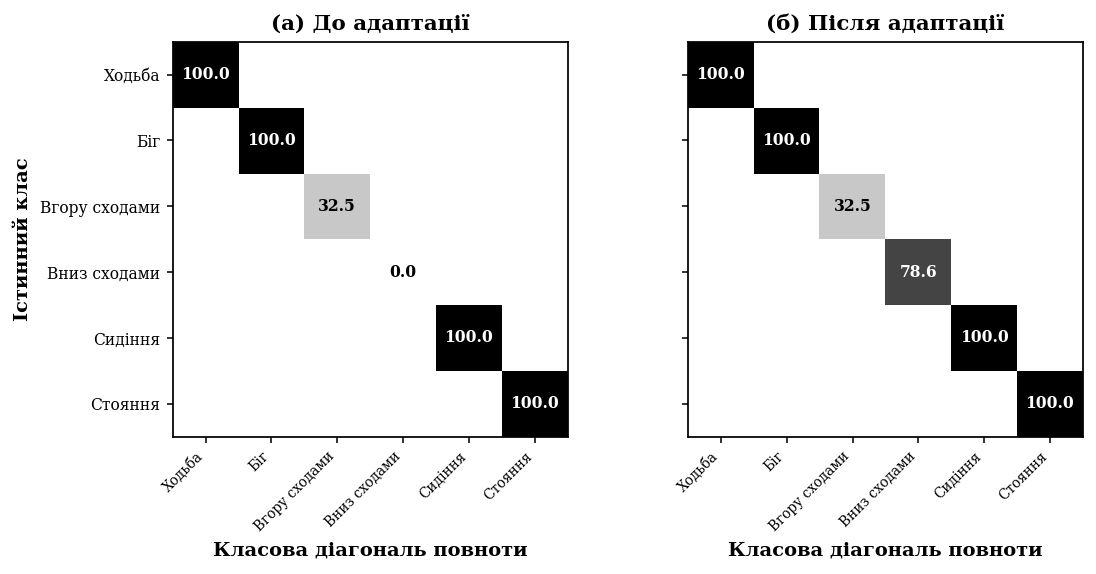

In [34]:
# Рисунок 8: heatmap повноти класів для User 19 до/після адаптації.
# Це не повна confusion matrix: off-diagonal розподіл не логувався у run від 13 травня.
import numpy as np

recall_heatmap_src = wisdm_user19_heldout[
    wisdm_user19_heldout["policy"].eq("reservoir")
].copy()
recall_heatmap_src["Клас"] = recall_heatmap_src["name"].map(CLASS_UK)
recall_heatmap_src["Стан"] = recall_heatmap_src["phase"].map(PHASE_UK)
recall_heatmap_src[["Стан", "Клас", "support", "correct", "recall_pct"]].to_csv(
    TABLE_DIR / "table_08_user19_recall_heatmap_uk.csv", index=False
)

class_order = [CLASS_UK[name] for name in CLASS_ORDER]
cmap = plt.get_cmap("Greys").copy()
cmap.set_bad(color="white")

fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.2), sharey=True)
for ax, phase, title in zip(axes, ["pre", "post"], ["(а) До адаптації", "(б) Після адаптації"]):
    rows = recall_heatmap_src[recall_heatmap_src["phase"].eq(phase)].sort_values("class")
    matrix = np.full((len(class_order), len(class_order)), np.nan)
    for class_idx, value in enumerate(rows["recall_pct"]):
        matrix[class_idx, class_idx] = float(value)

    im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=100, aspect="equal")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(len(class_order)))
    ax.set_xticklabels(class_order, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(class_order, fontsize=8)
    ax.set_xlabel("Класова діагональ повноти", fontweight="bold")
    if ax is axes[0]:
        ax.set_ylabel("Істинний клас", fontweight="bold")

    for class_idx, value in enumerate(rows["recall_pct"]):
        text_color = "white" if value > 60 else "black"
        ax.text(
            class_idx,
            class_idx,
            f"{value:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
            fontweight="bold",
        )
    style_axes(ax, grid_axis=None)

fig.subplots_adjust(wspace=0.18, bottom=0.26)
save_paper_figure("fig_08_user19_recall_heatmaps_uk")
plt.show()
